# Notebook 04 — Bi-LSTM + Attention + Integrated Gradients (Lintas 4 Subset)

**Arsitektur:**
```
Input (window=30, n_features) 
   ↓
Bi-LSTM(64, return_sequences=True) → Dropout(0.2)
   ↓
Bi-LSTM(32, return_sequences=True) → Dropout(0.2)
   ↓
Self-Attention layer (additive)
   ↓
Dense(32, ReLU) → Dropout(0.2)
   ↓
Dense(1) → RUL
```

In [15]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Bidirectional, Dense, Dropout,
                                     Layer, Multiply, Permute, RepeatVector, Lambda)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
tf.random.set_seed(42)
np.random.seed(42)

PROCESSED_DIR = '../processed'
MODEL_DIR     = '../models'
OUTPUT_DIR    = '../output'
os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

SUBSETS    = ['FD001', 'FD002', 'FD003', 'FD004']
TRAIN_FLAG = True   # set False untuk skip training & load bobot tersimpan
EPOCHS     = 80
BATCH_SIZE = 256

print("TF version :", tf.__version__)
print("GPU avail  :", len(tf.config.list_physical_devices('GPU')))

TF version : 2.15.1
GPU avail  : 0


## 1. Custom Self-Attention Layer

Implementasi *additive attention* (Bahdanau-style) yang ringan dan kompatibel
dengan output Bi-LSTM.

In [16]:
class AttentionLayer(Layer):
    """Additive (Bahdanau-style) self-attention untuk sequence Bi-LSTM."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        # input_shape : (batch, time_steps, features)
        self.W = self.add_weight(name='att_W', shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='att_b', shape=(input_shape[1], 1),
                                 initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, x):
        # e : (batch, time, 1)
        e = tf.tanh(tf.matmul(x, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1)
        # weighted sum -> (batch, features)
        return tf.reduce_sum(x * a, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

## 2. Builder Arsitektur Bi-LSTM + Attention

In [17]:
def build_bilstm_attention(seq_length, n_features, lr=1e-3):
    inp = Input(shape=(seq_length, n_features))
    x = Bidirectional(LSTM(64, return_sequences=True))(inp)
    x = Dropout(0.2)(x)
    x = Bidirectional(LSTM(32, return_sequences=True))(x)
    x = Dropout(0.2)(x)
    x = AttentionLayer()(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(1)(x)
    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model

# Quick architecture preview
demo = build_bilstm_attention(seq_length=30, n_features=20)
demo.summary()

Model: "model_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 30, 20)]          0         
                                                                 
 bidirectional_12 (Bidirect  (None, 30, 128)           43520     
 ional)                                                          
                                                                 
 dropout_18 (Dropout)        (None, 30, 128)           0         
                                                                 
 bidirectional_13 (Bidirect  (None, 30, 64)            41216     
 ional)                                                          
                                                                 
 dropout_19 (Dropout)        (None, 30, 64)            0         
                                                                 
 attention_layer_6 (Attenti  (None, 64)                94  

## 3. Fungsi Evaluasi

In [18]:
def nasa_score(y_true, y_pred):
    diff = y_pred - y_true
    return float(np.sum(np.where(diff < 0,
                                  np.exp(-diff/13) - 1,
                                  np.exp( diff/10) - 1)))

def evaluate(y_true, y_pred, name=''):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    ns   = nasa_score(y_true, y_pred)
    print(f"  [{name}]  RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.4f}  NASA={ns:.1f}")
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'NASA_Score': ns}

## 4. Integrated Gradients

Implementasi vanilla Integrated Gradients (Sundararajan et al., 2017):
$$
\text{IG}_i(x) = (x_i - x_i') \times \int_{\alpha=0}^{1}
  \frac{\partial F(x' + \alpha(x - x'))}{\partial x_i} \, d\alpha
$$

In [19]:
def integrated_gradients(inputs, baseline, model, num_steps=50):
    inputs   = tf.cast(inputs,   tf.float32)
    baseline = tf.cast(baseline, tf.float32)
    alphas   = tf.linspace(0.0, 1.0, num_steps + 1)[:, tf.newaxis, tf.newaxis]

    delta              = inputs - baseline
    interpolated       = baseline + alphas * delta

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated)
    grads      = tape.gradient(preds, interpolated)
    avg_grads  = tf.reduce_mean(grads, axis=0)
    attribution = delta * avg_grads
    return attribution.numpy()  # shape: (1, time, features)

## 5. Pipeline Training + IG per-Subset

In [20]:
def run_lstm_pipeline(subset_id):
    print(f"\n{'='*70}\n  Bi-LSTM+Attention — {subset_id}\n{'='*70}")
    sdir = f'{PROCESSED_DIR}/{subset_id}'

    X_train = np.load(f'{sdir}/train_3d_features.npy')
    y_train = np.load(f'{sdir}/train_3d_labels.npy')
    X_test  = np.load(f'{sdir}/test_3d_features.npy')
    y_test  = np.load(f'{sdir}/test_3d_labels.npy')

    print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"  X_test : {X_test.shape}, y_test : {y_test.shape}")

    seq_length, n_features = X_train.shape[1], X_train.shape[2]

    model = build_bilstm_attention(seq_length, n_features)
    ckpt_path = f'{MODEL_DIR}/bilstm_{subset_id}.weights.h5'

    if TRAIN_FLAG:
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True,
                            save_weights_only=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5),
        ]
        history = model.fit(
            X_train, y_train,
            validation_split=0.10,
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            callbacks=callbacks, verbose=2)
        # Plot loss
        plt.figure(figsize=(8, 4))
        plt.plot(history.history['loss'],     label='Train Loss')
        plt.plot(history.history['val_loss'], label='Val Loss')
        plt.title(f'Bi-LSTM Loss Curve — {subset_id}', fontweight='bold')
        plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/lstm_loss_{subset_id}.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        if os.path.exists(ckpt_path):
            model.load_weights(ckpt_path)
            print(f"  Loaded weights from {ckpt_path}")
        else:
            print(f"  WARNING: weights not found at {ckpt_path}")

    # ---- Evaluasi ----
    y_pred_te = model.predict(X_test, verbose=0).flatten()
    y_pred_tr = model.predict(X_train, verbose=0).flatten()

    y_train_flat = y_train.flatten()
    y_test_flat  = y_test.flatten() if y_test.ndim > 1 else y_test

    metrics_te = evaluate(y_test_flat,  y_pred_te, name=f'{subset_id} TEST')
    metrics_tr = evaluate(y_train_flat, y_pred_tr, name=f'{subset_id} TRAIN')

    # ---- Plot pred vs actual ----
    plt.figure(figsize=(11, 4))
    plt.plot(y_test,    label='Actual RUL', linestyle='--', color='#1f77b4', linewidth=1.8)
    plt.plot(y_pred_te, label='Predicted',  color='#2ca02c', alpha=0.85, linewidth=1.8)
    plt.title(f'Bi-LSTM — {subset_id}: Actual vs Predicted RUL', fontweight='bold')
    plt.xlabel('Test Engine Index'); plt.ylabel('RUL (cycles)')
    plt.legend(); plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/lstm_pred_{subset_id}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ---- Integrated Gradients ----
    print(f"  [IG] Computing Integrated Gradients for {subset_id} ...")
    with open(f'{sdir}/feature_list.json') as f:
        feature_cols = json.load(f)
    if len(feature_cols) != n_features:
        feature_cols = [f'F{i}' for i in range(n_features)]

    # Hitung IG untuk SEMUA test samples lalu rata-ratakan -> global feature importance
    ig_global = np.zeros(n_features)
    n_eval    = min(50, len(X_test))           # limit sampling biar cepat
    for idx in range(n_eval):
        sample = X_test[idx:idx+1]
        baseline = np.zeros_like(sample)
        ig = integrated_gradients(sample, baseline, model)  # (1, time, feat)
        # sum over time -> (feat,)
        ig_global += np.abs(ig.sum(axis=1)[0])
    ig_global = ig_global / n_eval

    ig_df = pd.DataFrame({'Feature': feature_cols,
                          'IG_Importance': ig_global}).sort_values('IG_Importance',
                                                                    ascending=False)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=ig_df.head(15), x='IG_Importance', y='Feature', palette='magma')
    plt.title(f'Integrated Gradients (Global) — Bi-LSTM {subset_id}', fontweight='bold')
    plt.xlabel('|IG| averaged over test samples')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/xai_ig_global_{subset_id}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ---- IG lokal untuk unit kritis ----
    idx_critical = int(np.argmin(y_test))
    sample   = X_test[idx_critical:idx_critical+1]
    baseline = np.zeros_like(sample)
    ig_local = integrated_gradients(sample, baseline, model)[0]   # (time, feat)
    ig_local_summed = np.abs(ig_local).sum(axis=0)
    local_df = pd.DataFrame({'Feature': feature_cols,
                             'IG_Local': ig_local_summed}).sort_values('IG_Local',
                                                                        ascending=False)
    plt.figure(figsize=(9, 6))
    sns.barplot(data=local_df.head(15), x='IG_Local', y='Feature', palette='magma')
    plt.title(f'IG Local — {subset_id} (Engine idx={idx_critical}, True RUL={y_test[idx_critical]:.0f})',
              fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/xai_ig_local_{subset_id}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ---- Simpan artefak ----
    pd.DataFrame({'y_true': y_test, 'y_pred_lstm': y_pred_te}).to_csv(
        f'{sdir}/lstm_predictions.csv', index=False)
    with open(f'{sdir}/lstm_metrics.json', 'w') as f:
        json.dump({'test': metrics_te, 'train': metrics_tr}, f, indent=2)
    ig_df.to_csv(f'{sdir}/lstm_ig_global.csv', index=False)

    return {
        'subset'       : subset_id,
        'metrics_test' : metrics_te,
        'metrics_train': metrics_tr,
        'ig_top5'      : ig_df.head(5).to_dict(orient='records'),
    }

## 6. Eksekusi Lintas 4 Subset


  Bi-LSTM+Attention — FD001
  X_train: (17631, 30, 17), y_train: (17631, 1)
  X_test : (100, 30, 17), y_test : (100,)
Epoch 1/80
62/62 - 12s - loss: 6610.0723 - mae: 70.3879 - val_loss: 5564.7666 - val_mae: 64.6108 - lr: 0.0010 - 12s/epoch - 190ms/step
Epoch 2/80
62/62 - 4s - loss: 3720.7568 - mae: 51.7583 - val_loss: 2881.1985 - val_mae: 47.2829 - lr: 0.0010 - 4s/epoch - 72ms/step
Epoch 3/80
62/62 - 8s - loss: 2164.2837 - mae: 40.8336 - val_loss: 1905.9821 - val_mae: 39.5806 - lr: 0.0010 - 8s/epoch - 130ms/step
Epoch 4/80
62/62 - 11s - loss: 1871.3182 - mae: 38.1351 - val_loss: 1793.4946 - val_mae: 38.2560 - lr: 0.0010 - 11s/epoch - 178ms/step
Epoch 5/80
62/62 - 10s - loss: 1870.3821 - mae: 37.9335 - val_loss: 1790.2086 - val_mae: 38.2076 - lr: 0.0010 - 10s/epoch - 165ms/step
Epoch 6/80
62/62 - 10s - loss: 1853.4417 - mae: 37.6802 - val_loss: 1786.0439 - val_mae: 38.1563 - lr: 0.0010 - 10s/epoch - 162ms/step
Epoch 7/80
62/62 - 9s - loss: 1884.2334 - mae: 38.0742 - val_loss: 1789.1040

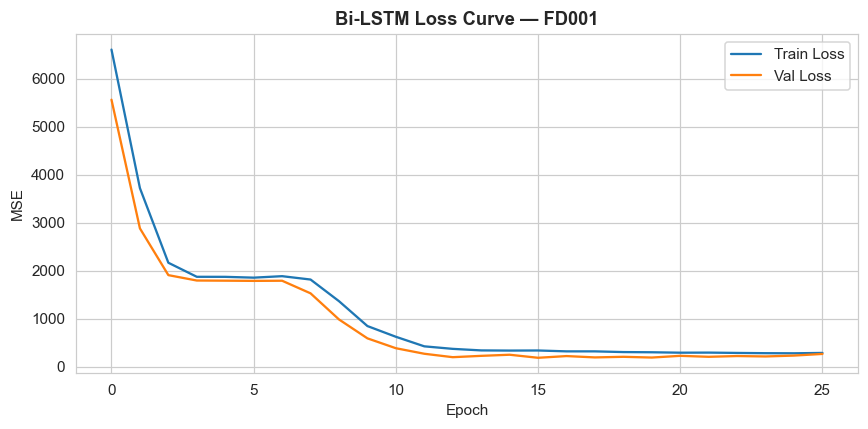

  [FD001 TEST]  RMSE=15.352  MAE=11.606  R2=0.8635  NASA=392.0
  [FD001 TRAIN]  RMSE=13.794  MAE=10.455  R2=0.8910  NASA=66541.1


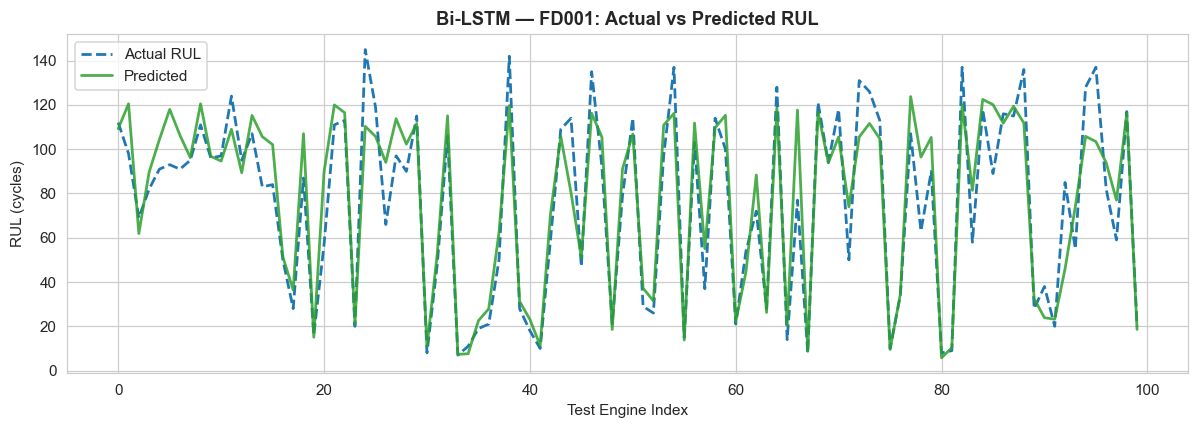

  [IG] Computing Integrated Gradients for FD001 ...


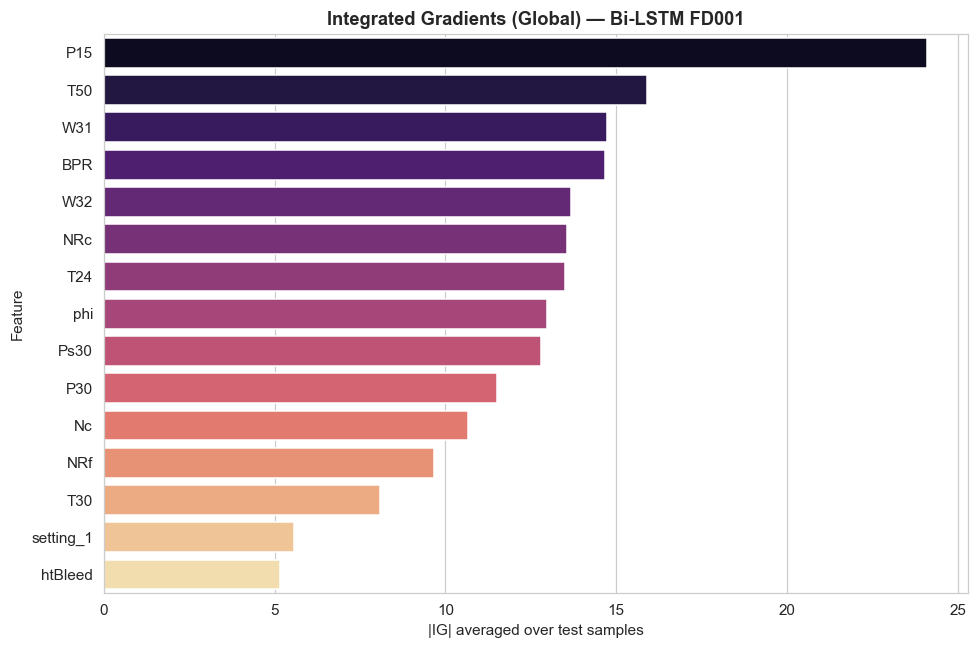

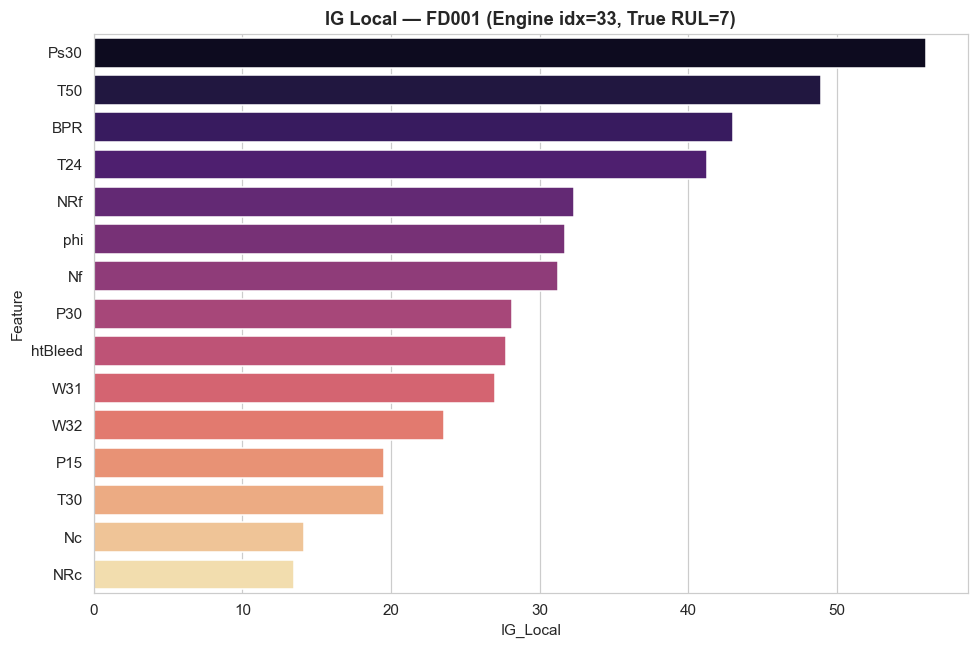


  Bi-LSTM+Attention — FD002
  X_train: (45959, 30, 24), y_train: (45959, 1)
  X_test : (259, 30, 24), y_test : (259,)
Epoch 1/80
162/162 - 14s - loss: 4488.1377 - mae: 56.5608 - val_loss: 2008.2970 - val_mae: 40.3933 - lr: 0.0010 - 14s/epoch - 89ms/step
Epoch 2/80
162/162 - 10s - loss: 1867.5935 - mae: 38.0278 - val_loss: 1796.7719 - val_mae: 38.1432 - lr: 0.0010 - 10s/epoch - 61ms/step
Epoch 3/80
162/162 - 10s - loss: 1862.2767 - mae: 37.8701 - val_loss: 1796.2609 - val_mae: 38.1360 - lr: 0.0010 - 10s/epoch - 60ms/step
Epoch 4/80
162/162 - 10s - loss: 1858.3041 - mae: 37.8469 - val_loss: 1794.2677 - val_mae: 38.1046 - lr: 0.0010 - 10s/epoch - 60ms/step
Epoch 5/80
162/162 - 10s - loss: 1565.8300 - mae: 33.9935 - val_loss: 519.6271 - val_mae: 19.0809 - lr: 0.0010 - 10s/epoch - 60ms/step
Epoch 6/80
162/162 - 10s - loss: 559.2904 - mae: 18.3838 - val_loss: 386.8094 - val_mae: 15.0893 - lr: 0.0010 - 10s/epoch - 64ms/step
Epoch 7/80
162/162 - 11s - loss: 510.1932 - mae: 17.2841 - val_loss:

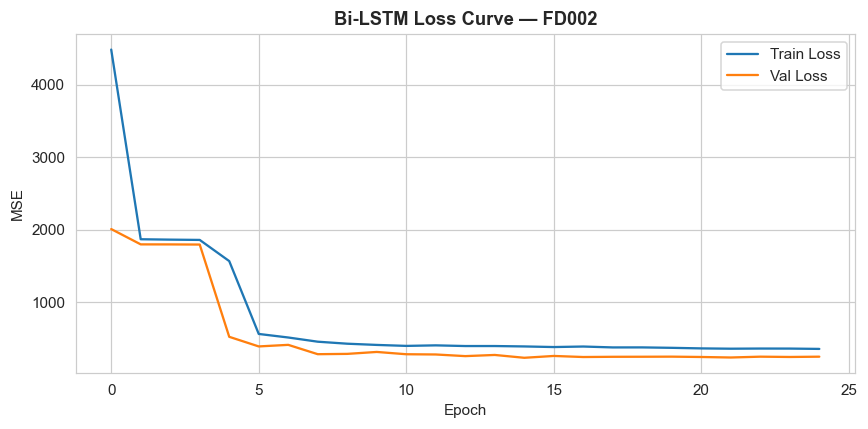

  [FD002 TEST]  RMSE=27.920  MAE=18.914  R2=0.7305  NASA=9075.8
  [FD002 TRAIN]  RMSE=15.761  MAE=11.667  R2=0.8577  NASA=275380.2


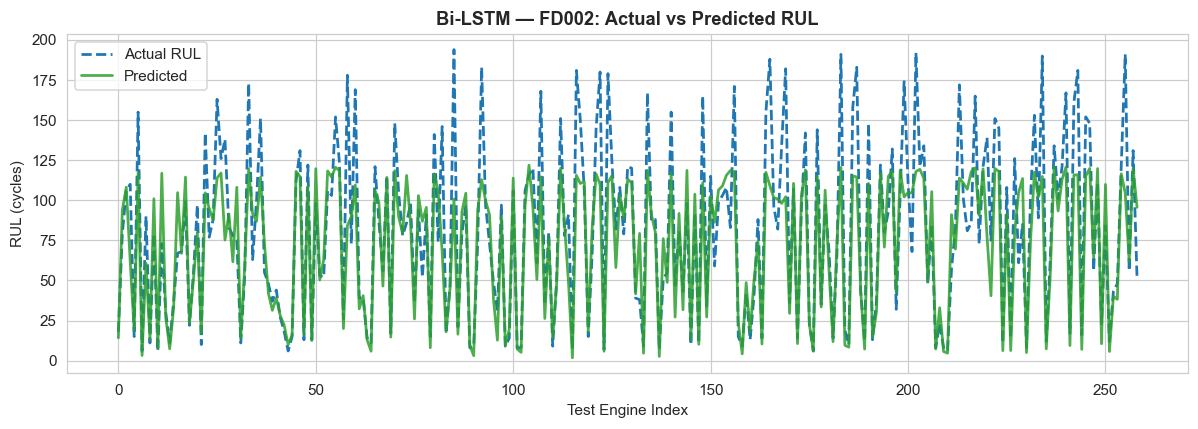

  [IG] Computing Integrated Gradients for FD002 ...


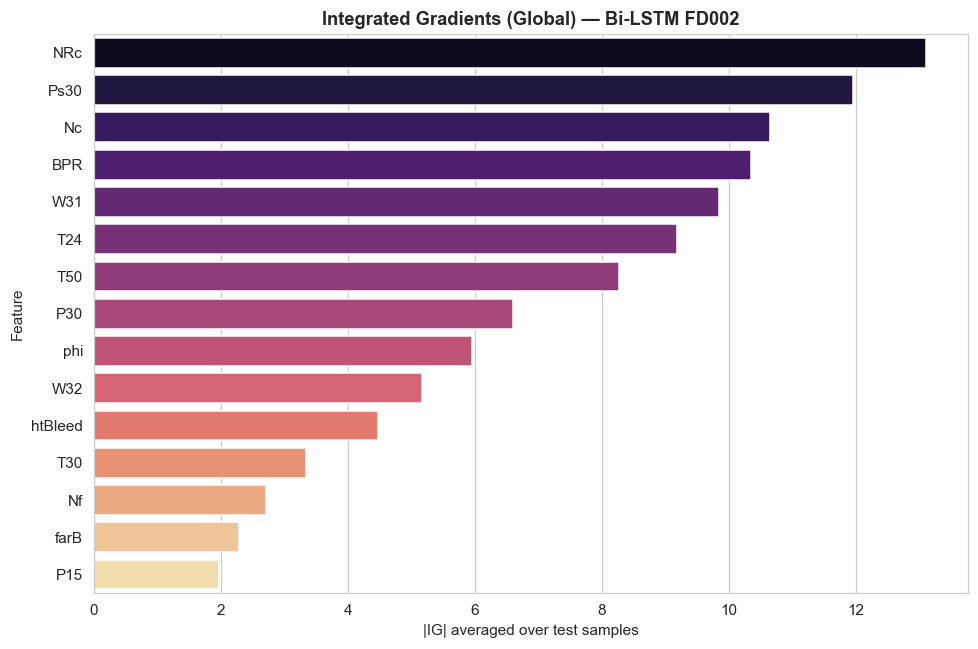

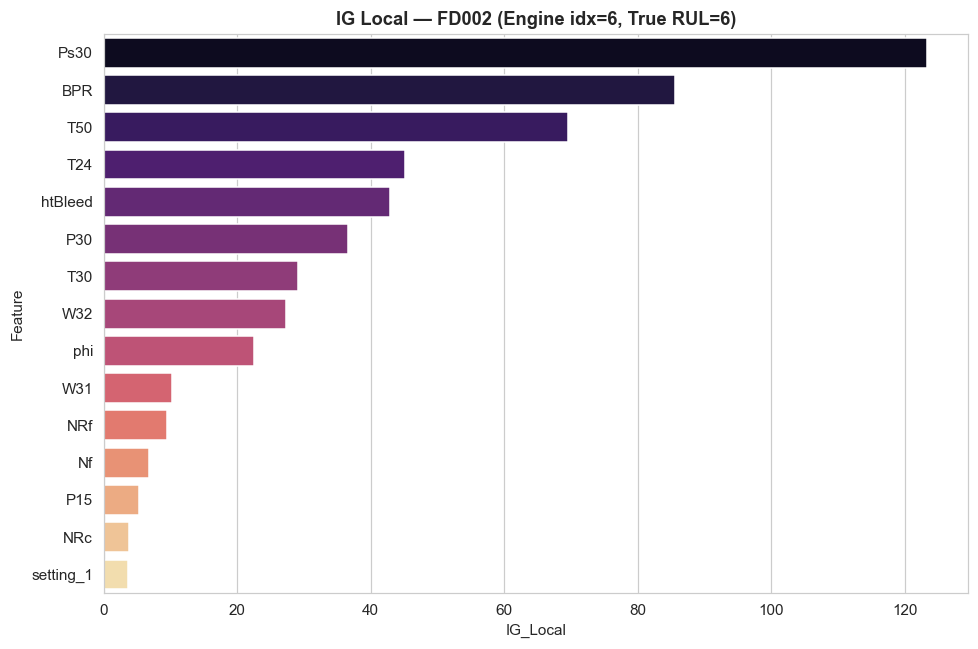


  Bi-LSTM+Attention — FD003
  X_train: (21720, 30, 18), y_train: (21720, 1)
  X_test : (100, 30, 18), y_test : (100,)
Epoch 1/80
77/77 - 9s - loss: 7326.4761 - mae: 75.7916 - val_loss: 4748.3384 - val_mae: 59.7071 - lr: 0.0010 - 9s/epoch - 115ms/step
Epoch 2/80
77/77 - 5s - loss: 3374.5835 - mae: 51.2354 - val_loss: 2078.5081 - val_mae: 41.5804 - lr: 0.0010 - 5s/epoch - 59ms/step
Epoch 3/80
77/77 - 4s - loss: 1925.9132 - mae: 39.1224 - val_loss: 1783.4249 - val_mae: 37.6489 - lr: 0.0010 - 4s/epoch - 58ms/step
Epoch 4/80
77/77 - 4s - loss: 1853.0054 - mae: 37.5937 - val_loss: 1784.7158 - val_mae: 37.4971 - lr: 0.0010 - 4s/epoch - 57ms/step
Epoch 5/80
77/77 - 4s - loss: 1848.4635 - mae: 37.4212 - val_loss: 1783.9026 - val_mae: 37.5189 - lr: 0.0010 - 4s/epoch - 57ms/step
Epoch 6/80
77/77 - 4s - loss: 1839.2036 - mae: 37.3928 - val_loss: 1782.7281 - val_mae: 37.4483 - lr: 0.0010 - 4s/epoch - 58ms/step
Epoch 7/80
77/77 - 5s - loss: 1835.2701 - mae: 37.2379 - val_loss: 1773.9901 - val_mae: 

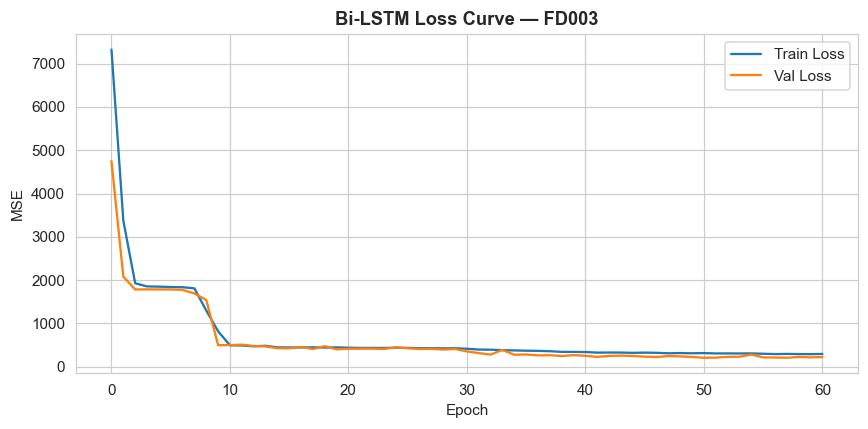

  [FD003 TEST]  RMSE=17.331  MAE=12.948  R2=0.8247  NASA=709.8
  [FD003 TRAIN]  RMSE=12.767  MAE=8.635  R2=0.9052  NASA=78300.9


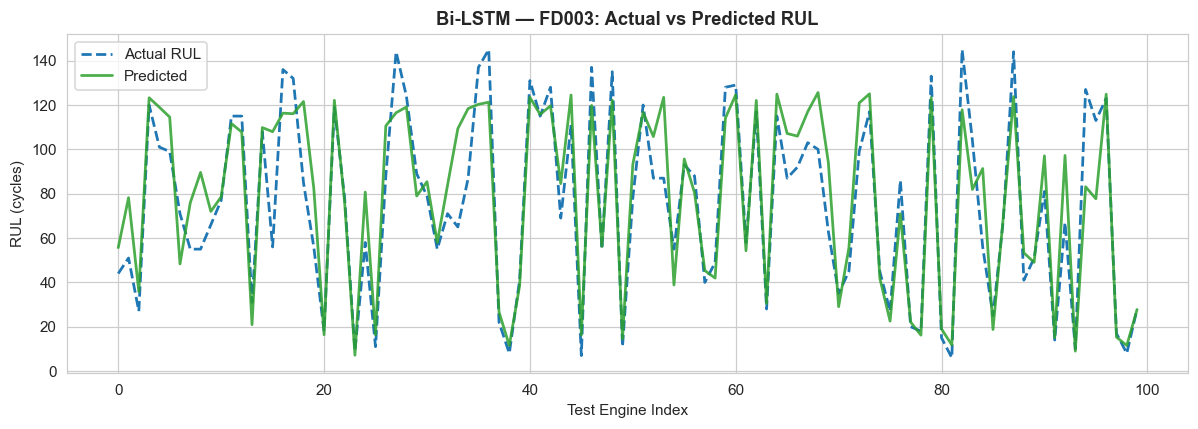

  [IG] Computing Integrated Gradients for FD003 ...


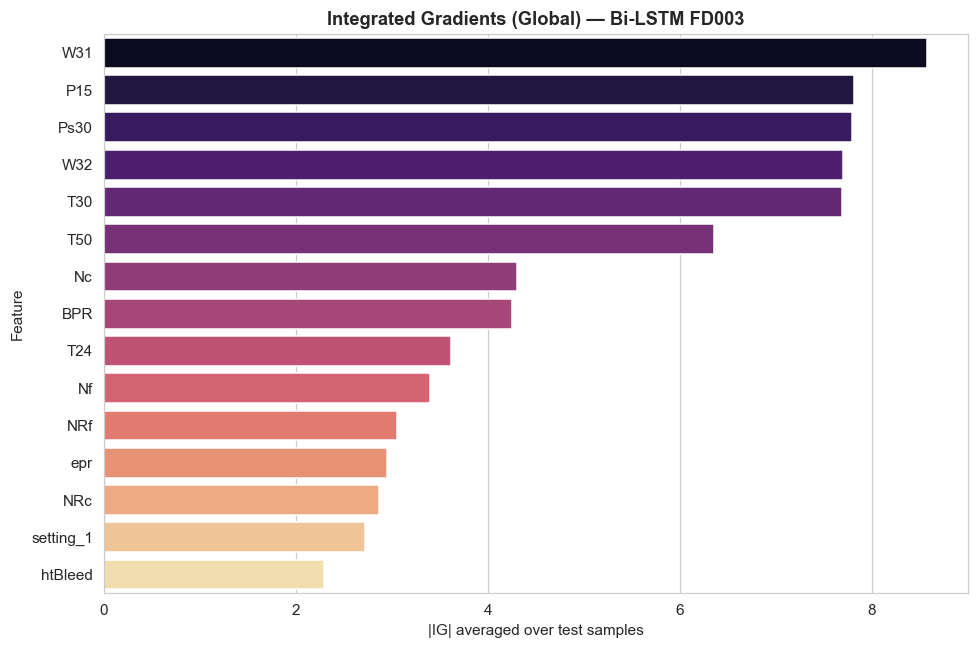

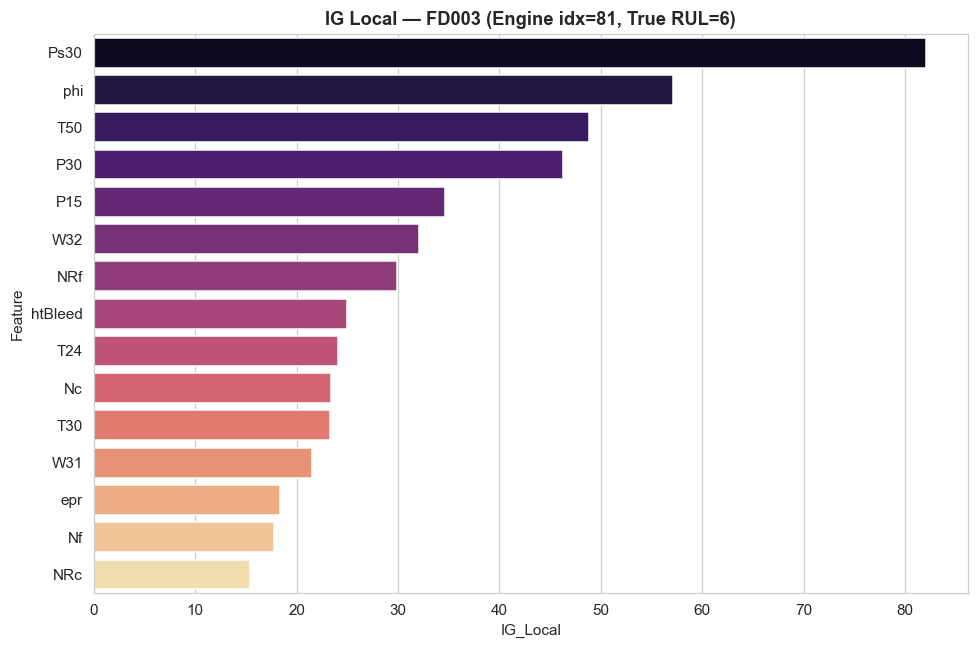


  Bi-LSTM+Attention — FD004
  X_train: (53779, 30, 24), y_train: (53779, 1)
  X_test : (248, 30, 24), y_test : (248,)
Epoch 1/80
190/190 - 17s - loss: 4772.8633 - mae: 59.4721 - val_loss: 1845.6169 - val_mae: 39.2280 - lr: 0.0010 - 17s/epoch - 89ms/step
Epoch 2/80
190/190 - 12s - loss: 1880.3402 - mae: 37.9947 - val_loss: 1721.3083 - val_mae: 36.9566 - lr: 0.0010 - 12s/epoch - 63ms/step
Epoch 3/80
190/190 - 12s - loss: 1678.3777 - mae: 35.5038 - val_loss: 545.0190 - val_mae: 20.5607 - lr: 0.0010 - 12s/epoch - 61ms/step
Epoch 4/80
190/190 - 12s - loss: 559.8806 - mae: 18.2909 - val_loss: 321.2654 - val_mae: 13.0054 - lr: 0.0010 - 12s/epoch - 62ms/step
Epoch 5/80
190/190 - 12s - loss: 527.6832 - mae: 17.5210 - val_loss: 315.7657 - val_mae: 13.0708 - lr: 0.0010 - 12s/epoch - 61ms/step
Epoch 6/80
190/190 - 12s - loss: 518.9262 - mae: 17.3780 - val_loss: 294.5274 - val_mae: 12.1251 - lr: 0.0010 - 12s/epoch - 61ms/step
Epoch 7/80
190/190 - 12s - loss: 507.0436 - mae: 17.1490 - val_loss: 303

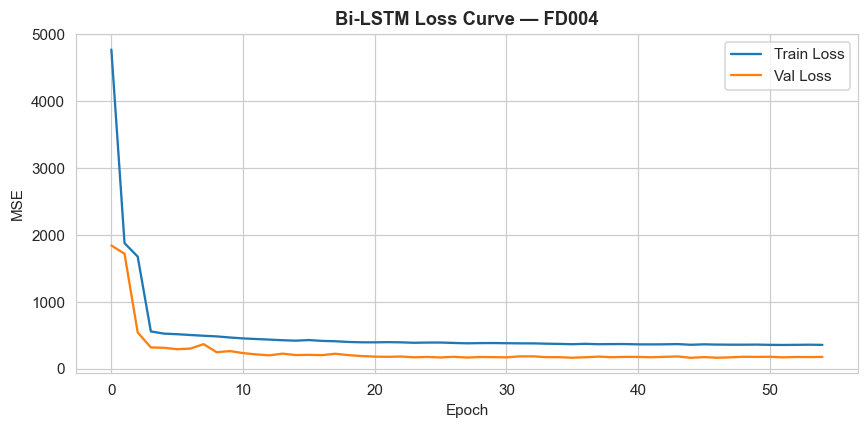

  [FD004 TEST]  RMSE=33.404  MAE=22.277  R2=0.6247  NASA=178903.5
  [FD004 TRAIN]  RMSE=13.714  MAE=9.360  R2=0.8908  NASA=365849.0


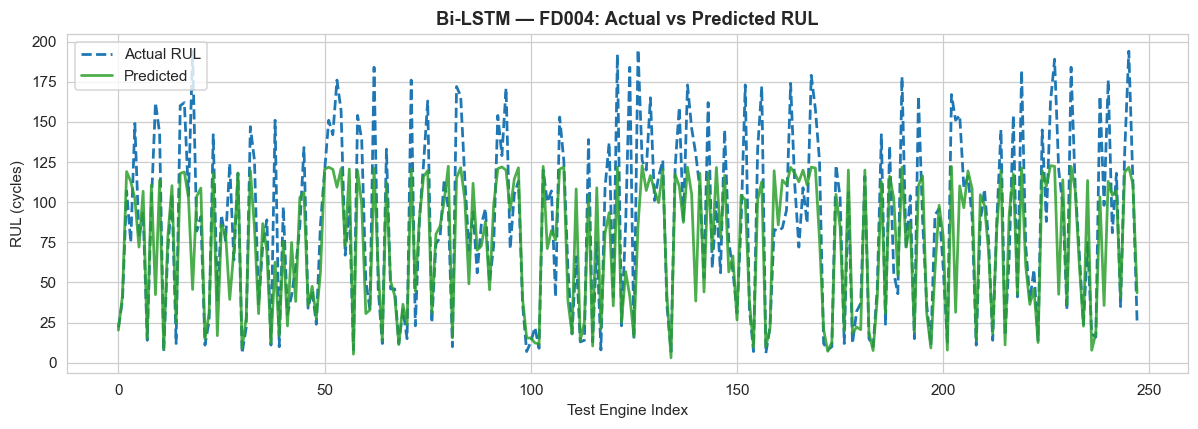

  [IG] Computing Integrated Gradients for FD004 ...


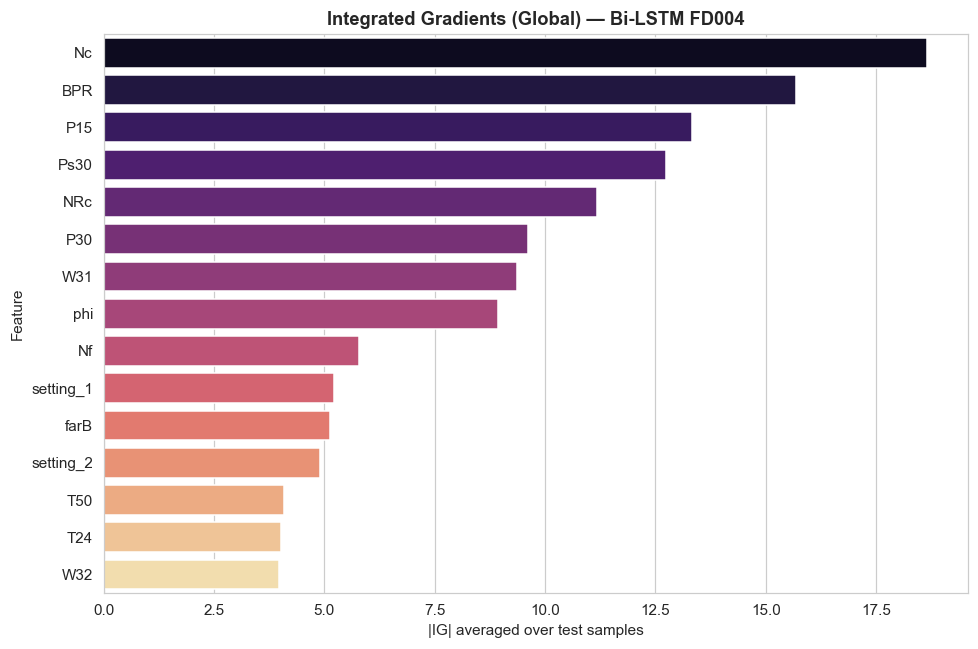

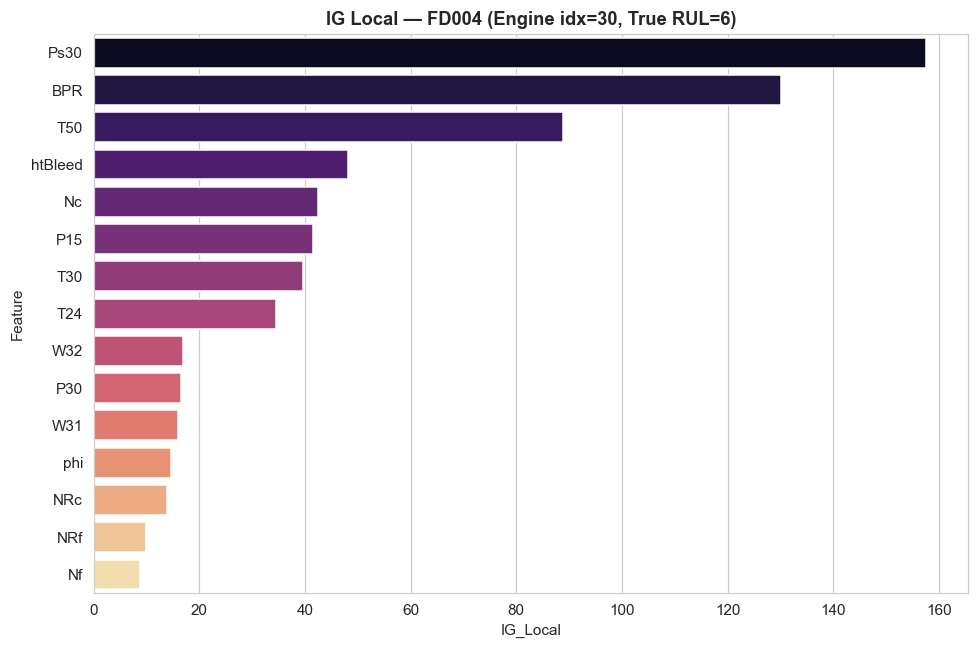


=== Ringkasan Bi-LSTM Lintas 4 Subset ===


,subset,test_RMSE,test_MAE,test_R2,test_NASA_Score,train_RMSE,train_MAE,train_R2,train_NASA_Score
0,FD001,15.352,11.606,0.864,392.016,13.794,10.455,0.891,66541.055
1,FD002,27.920,18.914,0.730,9075.761,15.761,11.667,0.858,275380.219
2,FD003,17.331,12.948,0.825,709.820,12.767,8.635,0.905,78300.914
3,FD004,33.404,22.277,0.625,178903.469,13.714,9.360,0.891,365849.031


In [21]:
all_results = []
for s in SUBSETS:
    all_results.append(run_lstm_pipeline(s))

# Tabel ringkasan
rows = []
for r in all_results:
    row = {'subset': r['subset']}
    row.update({f"test_{k}": v  for k, v in r['metrics_test'].items()})
    row.update({f"train_{k}": v for k, v in r['metrics_train'].items()})
    rows.append(row)
lstm_summary = pd.DataFrame(rows)
lstm_summary.to_csv(f'{PROCESSED_DIR}/lstm_cross_summary.csv', index=False)
print("\n=== Ringkasan Bi-LSTM Lintas 4 Subset ===")
lstm_summary.round(3)

## 7. Visualisasi Komparasi RMSE Bi-LSTM Lintas Subset

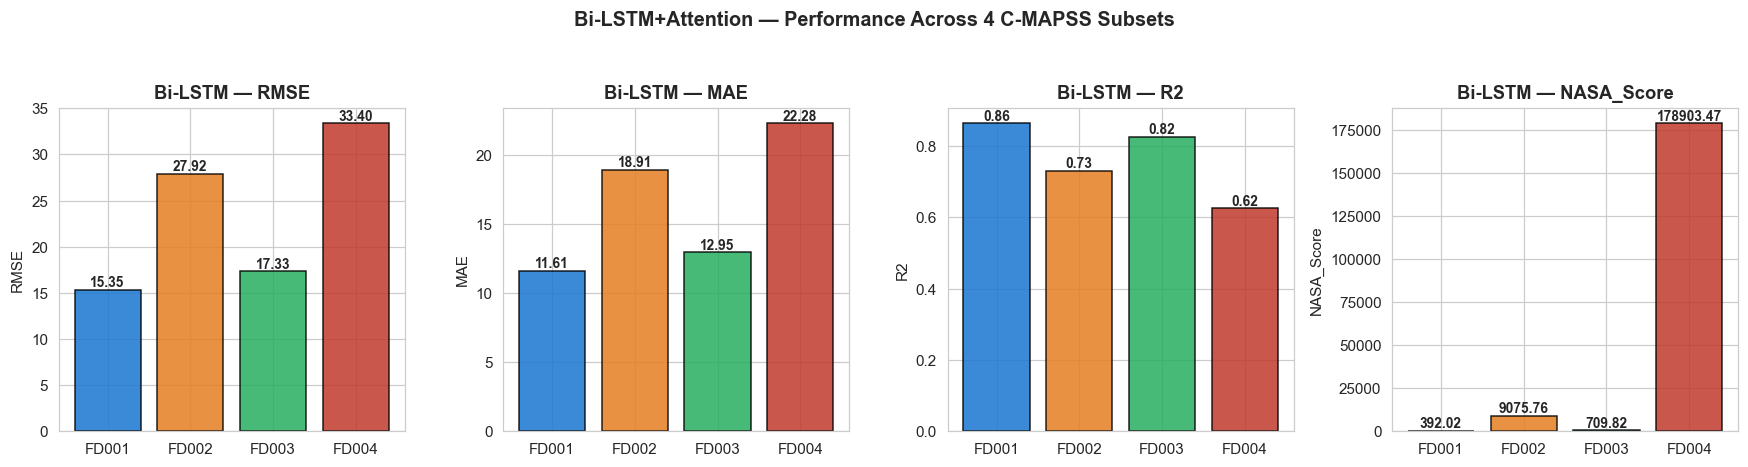

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ['RMSE', 'MAE', 'R2', 'NASA_Score']
for i, m in enumerate(metrics):
    vals = [r['metrics_test'][m] for r in all_results]
    bars = axes[i].bar(SUBSETS, vals, color=['#1976D2','#E67E22','#27AE60','#C0392B'],
                       edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Bi-LSTM — {m}', fontweight='bold')
    axes[i].set_ylabel(m)
    for b, v in zip(bars, vals):
        axes[i].text(b.get_x()+b.get_width()/2, v, f'{v:.2f}',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.suptitle('Bi-LSTM+Attention — Performance Across 4 C-MAPSS Subsets',
             fontweight='bold', fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lstm_metrics_4subsets.png', dpi=300, bbox_inches='tight')
plt.show()